# From Plankton to Particles — Tracing Oceanic DMS to Climate-Active Aerosols”

| Experiment Folder       | Shorthand | "Story-line" Being Simulated                                                                 | What Changes Compared with Baseline                                                                 | Why We Look at EMIDMS Here                                                                 |
|-------------------------|-----------------------|-------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------|
| `baseline`              | piControl | Perpetual-year simulation that mimics ~1850 CE conditions. It is the reference against which every perturbation run is compared. | same SST, sea-ice, trace-gas emissions as in the control protocol)                            | Gives the "background" natural oceanic DMS emission pattern that interacts with aerosols. |
| `future_ssp585`         | SSP585              | A high-end warming pathway with fossil-fuel dominated economy. Sea-surface temperature (SST), sea-ice and greenhouse-gas forcing all follow the CMIP6 SSP585 scenario. | Everything evolves (SST↑, sea-ice↓, atmospheric chemistry ↔).                                     | Shows the net (ocean + climate + host-chemistry) response of DMS emissions to a hot future world. |
| `seaice_contrib_ssp585` |                       | Only sea-ice concentration is taken from SSP585; SST and atmospheric composition stay at baseline. | Isolates the sea-ice loss channel. Ocean grid cells that become ice-free can emit more DMS.       | Lets you quantify just the sea-ice-driven change: ΔEMIDMS<sub>ice</sub> = run − baseline |
| `SST_contrib_ssp585`    |                       | Only SST follows SSP585; sea-ice and chemistry are baseline.                            | Isolates the warmer ocean channel (biological production & solubility).                           | Gives ΔEMIDMS<sub>SST</sub>. Together with the sea-ice run you can reconstruct the full ΔEMIDMS. |

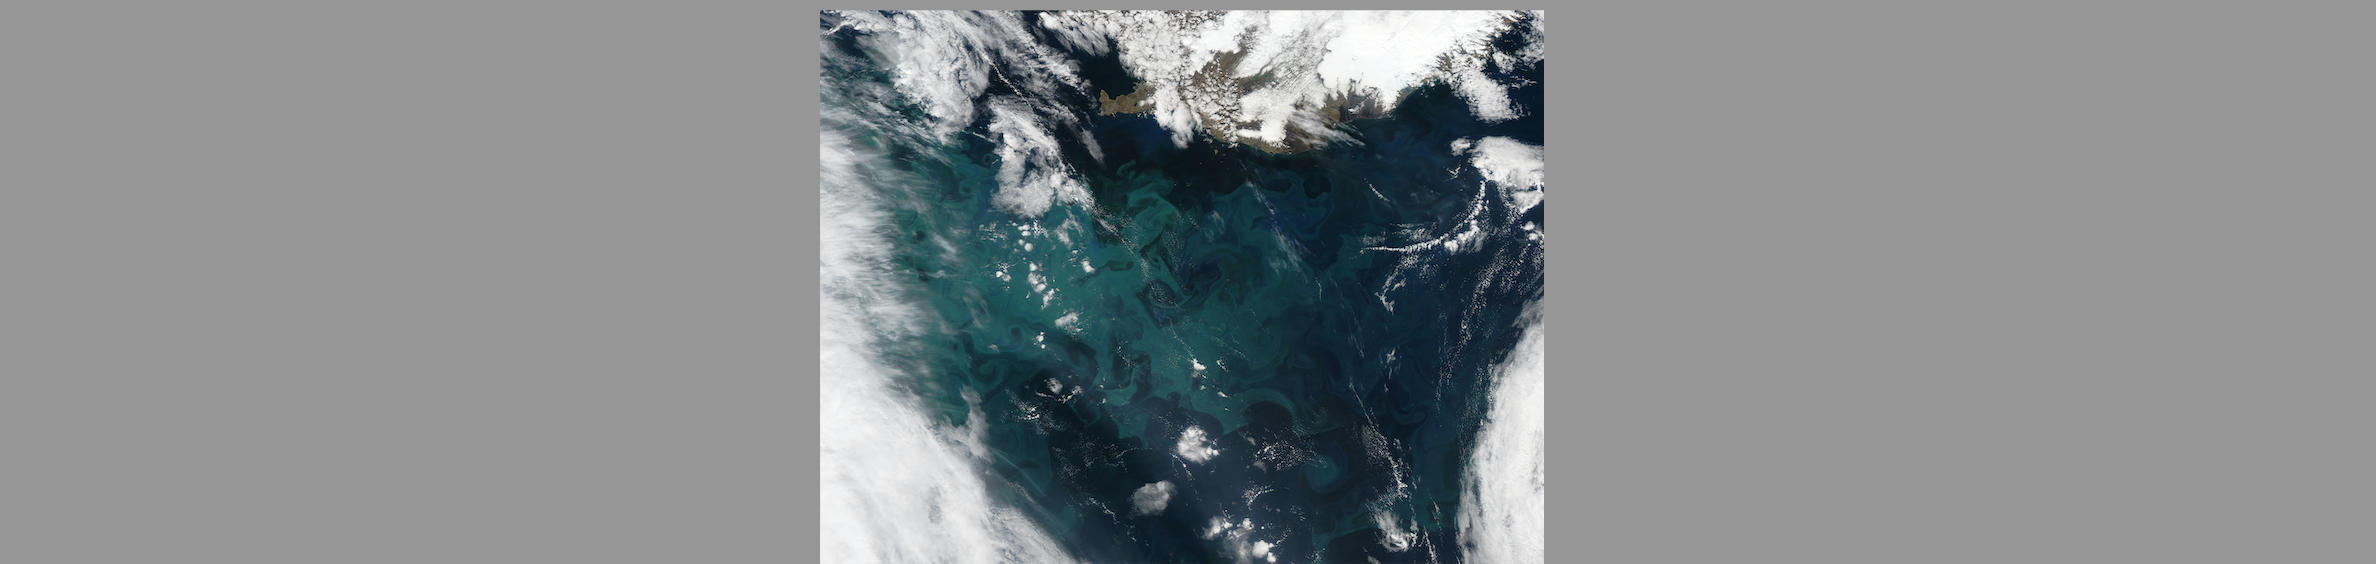

### Step_1: 
download all EMIDMS files
* Enter below code to the terminal
* 1 GB total (EMIDMS is a single 2-D field per month)
* 40 yr × 4 experiments = 160 files


In [1]:
#!/usr/bin/env bash
# set -euo pipefail                       # fail loud & early
# ##############################################################################
# INPUT_ROOT="https://crices-task33-output-ecearth.lake.fmi.fi"
# MODEL="EC-Earth"
# EXPS=( baseline future_ssp585 seaice_contrib_ssp585 SST_contrib_ssp585 )
# YEARS=( $(printf "%04d " {0..39}) )     # 0000 … 0039 inclusive
# VAR="EMIDMS"
# OUT="./emidms_download"                 # keeps your project folder tidy
# mkdir -p "$OUT"

# for EXP in "${EXPS[@]}"; do
#   echo "=== ${EXP} ==="
#   mkdir -p "$OUT/${EXP}"
#   for Y in "${YEARS[@]}"; do
#     FILE="${VAR}_${MODEL}_${EXP}_monthly_singlelevel_${Y}-01-01_${Y}-12-31.nc"
#     URL="${INPUT_ROOT}/${VAR}/${EXP}/${FILE}"
#     echo "  ↓ $FILE"
#     # -nc  = no-clobber (skip if already downloaded)
#     # -q   = quiet (comment this out for verbose)
#     wget -nc -q -P "$OUT/${EXP}" "$URL"
#   done
# done
# echo "✅ All done – files are in $OUT/*/"

In [2]:
from Common_import2 import *

## Step_2: 
* store data in dictionary

In [3]:
model_data2 = build_emidms_dict(
    dl_root   = "./emidms_download",
    model_key = "EC-Earth",     # <- exactly as in the NetCDF names
    exps      = ("baseline",
                 "future_ssp585",
                 "seaice_contrib_ssp585",
                 "SST_contrib_ssp585")
)

✅ loaded EC-Earth/baseline: 480 mon × 90 × 120 (lazy)
✅ loaded EC-Earth/future_ssp585: 480 mon × 90 × 120 (lazy)
✅ loaded EC-Earth/seaice_contrib_ssp585: 480 mon × 90 × 120 (lazy)
✅ loaded EC-Earth/SST_contrib_ssp585: 480 mon × 90 × 120 (lazy)


In [4]:
emi_results, emi_data = analyze_emidms(model_data2)

In [5]:
print_emidms(emi_results, prec=3, auto=True)


Model: EC-Earth
  Experiment: baseline
    Global   : 3.258e+00 pkg m⁻² s⁻¹
    Arctic   : 6.074e-01 pkg m⁻² s⁻¹
    Antarctic: 8.257e-01 pkg m⁻² s⁻¹
  Experiment: future_ssp585
    Global   : 3.449e+00 pkg m⁻² s⁻¹
    Arctic   : 1.179e+00 pkg m⁻² s⁻¹
    Antarctic: 1.279e+00 pkg m⁻² s⁻¹
  Experiment: seaice_contrib_ssp585
    Global   : 3.316e+00 pkg m⁻² s⁻¹
    Arctic   : 1.035e+00 pkg m⁻² s⁻¹
    Antarctic: 1.141e+00 pkg m⁻² s⁻¹
  Experiment: SST_contrib_ssp585
    Global   : 3.392e+00 pkg m⁻² s⁻¹
    Arctic   : 7.014e-01 pkg m⁻² s⁻¹
    Antarctic: 9.115e-01 pkg m⁻² s⁻¹


In [6]:
plot_all_data_maps(emi_data, variable_name="EMIDMS",
                   save_dir="plots_emidms", cmap="turbo",
                   unit="kg m⁻² s⁻¹", smooth=False, dpi=400,
    land_color="white", ocean_color="#CFE9FF",
    add_area_names=True)

Plotting EC-Earth / baseline / Global
Plotting EC-Earth / baseline / Arctic
Plotting EC-Earth / baseline / Antarctic
Plotting EC-Earth / future_ssp585 / Global
Plotting EC-Earth / future_ssp585 / Arctic
Plotting EC-Earth / future_ssp585 / Antarctic
Plotting EC-Earth / seaice_contrib_ssp585 / Global
Plotting EC-Earth / seaice_contrib_ssp585 / Arctic
Plotting EC-Earth / seaice_contrib_ssp585 / Antarctic
Plotting EC-Earth / SST_contrib_ssp585 / Global
Plotting EC-Earth / SST_contrib_ssp585 / Arctic
Plotting EC-Earth / SST_contrib_ssp585 / Antarctic


In [7]:
from four_scenarios import plot_four_scenarios

da_baseline    = model_data2["EC-Earth"]["baseline"]["emidms"]
da_future      = model_data2["EC-Earth"]["future_ssp585"]["emidms"]
da_seaice      = model_data2["EC-Earth"]["seaice_contrib_ssp585"]["emidms"]
da_sst_contrib = model_data2["EC-Earth"]["SST_contrib_ssp585"]["emidms"]

scenario_data = {
    "baseline":            da_baseline,
    "future_ssp585":       da_future,
    "seaice_contrib":      da_seaice,
    "SST_contrib":         da_sst_contrib,
}

plot_four_scenarios(
    scenario_data,
    model="EC‑Earth",
    region="Arctic",
    variable_name="EMIDMS",
    unit="kg m⁻² s⁻¹",
    cmap="turbo",
    dpi=400,
    save_dir="figures"
)
